In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

print("All libraries loaded Successfully!")

All libraries loaded Successfully!


In [2]:
# Load the dataset
df = pd.read_csv("DnD_5e_Monsters_Stats.csv")

# First look at the data
print(df.shape)
print(df.head())

(428, 13)
                 Name  Armor Class  Hit Points  \
0           Aarakocra           12          13   
1             Aboleth           17         135   
2     Abominable Yeti           15         137   
3             Acolyte           10           9   
4  Adult Black Dragon           19         195   

                             Speed     CR  STR  DEX  CON  INT  WIS  CHA  \
0               20 ft., fly 50 ft.   0.25   10   14   10   11   12   11   
1              10 ft., swim 40 ft.  10.00   21    9   15   18   15   18   
2             40 ft., climb 40 ft.   9.00   24   10   22    9   13    9   
3                           30 ft.   0.25   10   10   10   10   14   11   
4  40 ft., fly 80 ft., swim 40 ft.  14.00   23   14   21   14   13   17   

                          Type       Alignment  
0  Medium humanoid (Aarakocra)    neutral good  
1             Large aberration     lawful evil  
2             Huge monstrosity    chaotic evil  
3   Medium humanoid (any race)   any align

In [3]:
# Check data types and missing values
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

Name               str
Armor Class      int64
Hit Points       int64
Speed              str
CR             float64
STR              int64
DEX              int64
CON              int64
INT              int64
WIS              int64
CHA              int64
Type               str
Alignment          str
dtype: object

Missing values:
Name           0
Armor Class    0
Hit Points     0
Speed          0
CR             0
STR            0
DEX            0
CON            0
INT            0
WIS            0
CHA            0
Type           0
Alignment      0
dtype: int64


In [4]:
# Explore target variable - Challenge Rating
print("CR summary statistics:")
print(df['CR'].describe())

print("\nUnique CR values:")
print(sorted(df['CR'].unique()))

CR summary statistics:
count    428.000000
mean       4.552278
std        5.596778
min        0.000000
25%        0.500000
50%        2.000000
75%        6.000000
max       30.000000
Name: CR, dtype: float64

Unique CR values:
[np.float64(0.0), np.float64(0.125), np.float64(0.25), np.float64(0.5), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0), np.float64(11.0), np.float64(12.0), np.float64(13.0), np.float64(14.0), np.float64(15.0), np.float64(16.0), np.float64(17.0), np.float64(18.0), np.float64(19.0), np.float64(20.0), np.float64(21.0), np.float64(22.0), np.float64(23.0), np.float64(24.0), np.float64(30.0)]


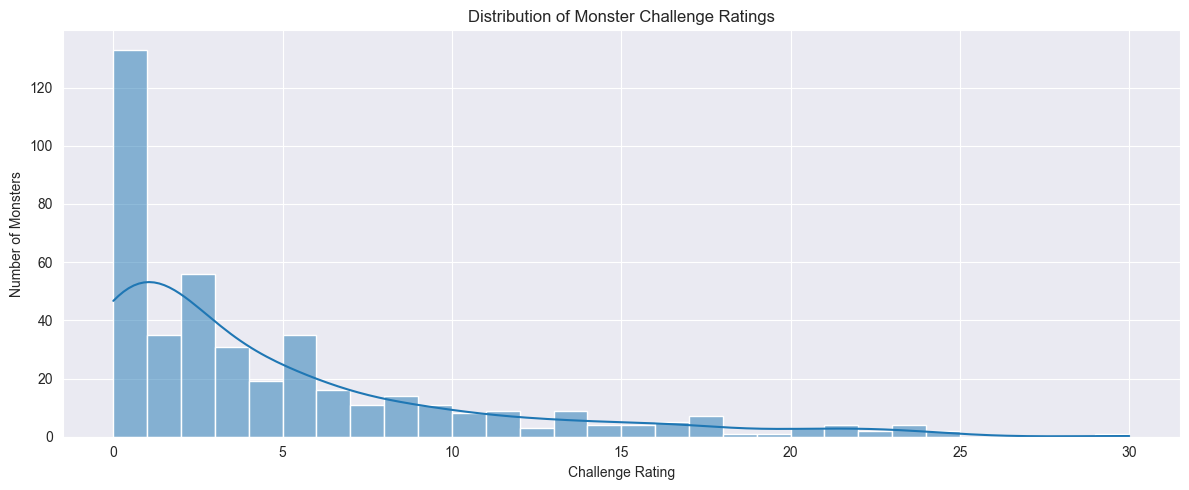

In [6]:
# Visualize CR distribution
plt.figure(figsize=(12, 5))
sns.histplot(df['CR'], bins=30, kde=True)
plt.title("Distribution of Monster Challenge Ratings")
plt.xlabel('Challenge Rating')
plt.ylabel('Number of Monsters')
plt.tight_layout()
plt.show()

In [8]:
# Correlation of numeric features with CR
numeric_cols = ['Armor Class', 'Hit Points', 'STR', 'DEX', 'CON', 'INT', 'WIS', 'CHA']
correlations = df[numeric_cols + ['CR']].corr()['CR'].drop('CR').sort_values(ascending=False)

print('Feature correlations with CR:')
print(correlations)

Feature correlations with CR:
Hit Points     0.933268
CON            0.824834
Armor Class    0.739156
CHA            0.683857
STR            0.677147
INT            0.604942
WIS            0.536870
DEX            0.013128
Name: CR, dtype: float64


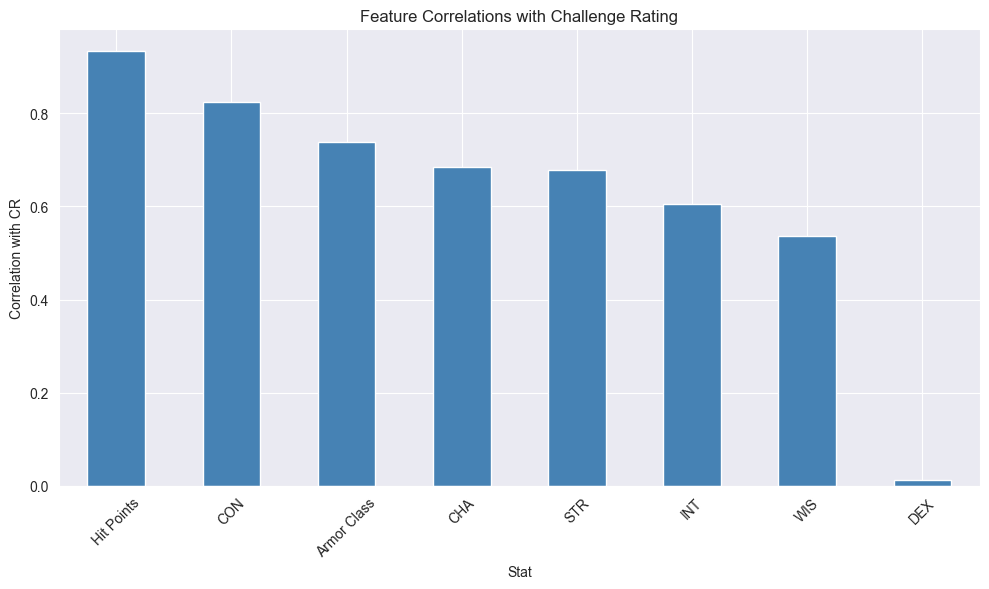

In [9]:
# Visualize feature correlations
plt.figure(figsize=(10, 6))
correlations.plot(kind="bar", color="steelblue")
plt.title("Feature Correlations with Challenge Rating")
plt.xlabel("Stat")
plt.ylabel("Correlation with CR")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()